In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")



Usando dispositivo: cpu


## 1. Dataset

In [7]:
df = pd.read_csv("../data/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Exploración y preparación de los datos
### 2.1 Dimensiones del dataset

In [ ]:
print(f"Numero de observaciones: {df.shape[0]}")
print(f"Numero de variables: {df.shape[1]}")
df.info()

El dataset contiene 
- 20,640 observaciones (distritos censales de California)
- 10 variables (9 features + 1 variable objetivo).

### 2.2 Descripción de variables

| Variable | Descripción |
|---|---|
| longitude | Longitud geográfica del distrito |
| latitude | Latitud geográfica del distrito |
| housing_median_age | Edad mediana de las viviendas en el distrito (años) |
| total_rooms | Número total de habitaciones en el distrito |
| total_bedrooms | Número total de dormitorios en el distrito |
| population | Población total del distrito |
| households | Número total de hogares en el distrito |
| median_income | Ingreso mediano de los hogares del distrito (en decenas de miles de USD) |
| ocean_proximity | Categoría de proximidad al océano (categórica) |
| median_house_value | valor mediano de las viviendas del distrito (USD) |

### 2.3 Valores nulos, duplicados y atípicos


Valores nulos por columna:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Filas duplicadas: 0
Valores nulos despues de imputacion: 0


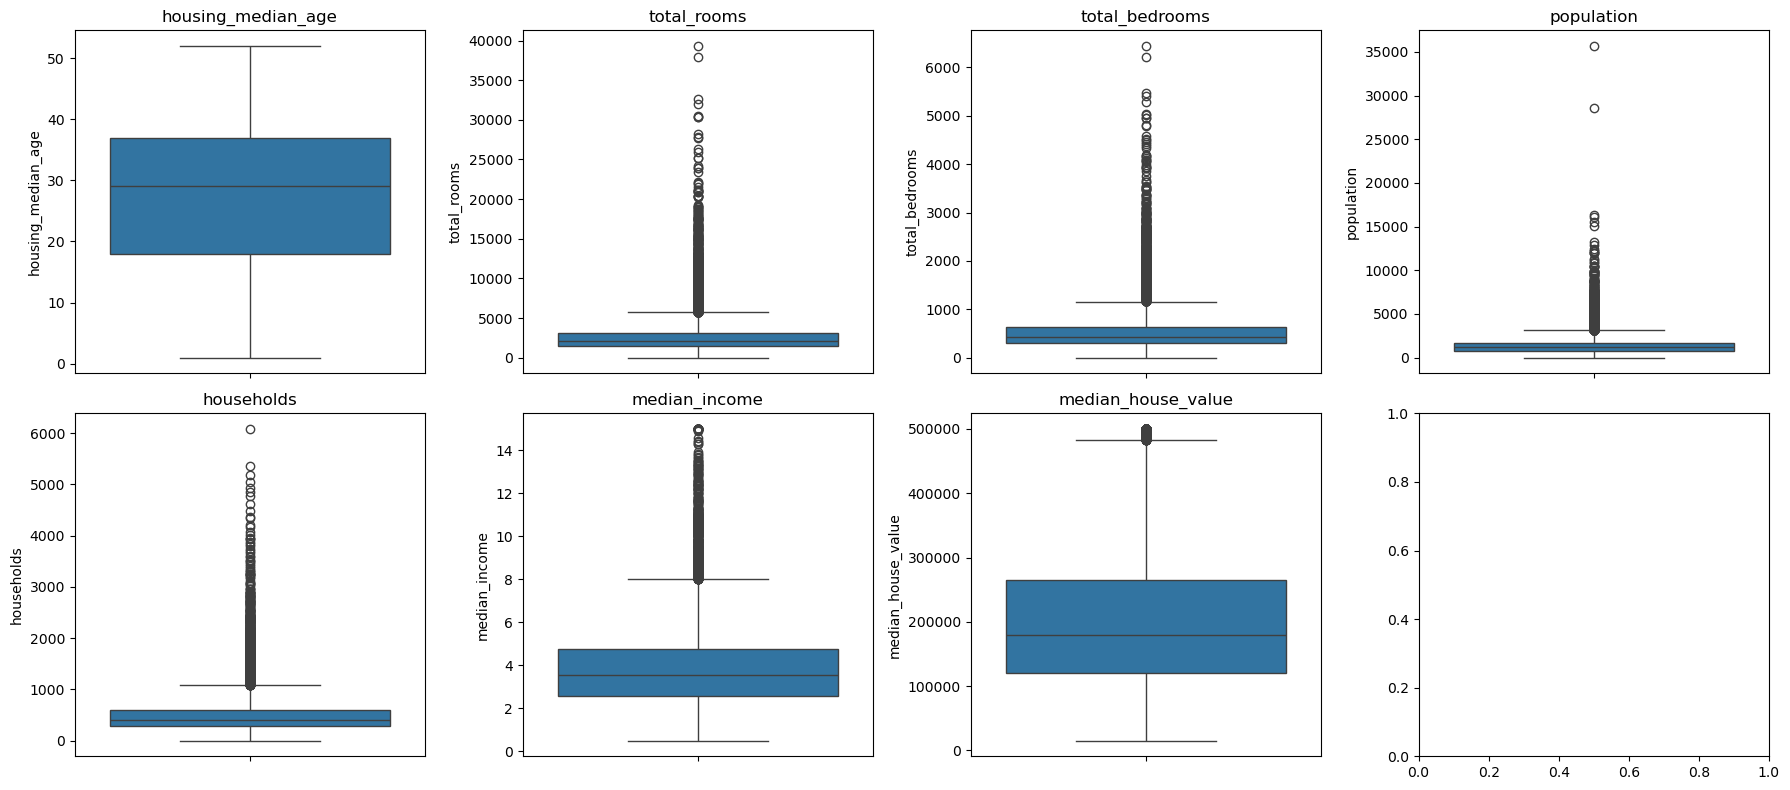

Valor maximo de median_house_value: 500001.0
Observaciones en el tope (500001): 965
Nuevo tamano del dataset: (19675, 10)


In [11]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")

df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
print("Valores nulos despues de imputacion:", df['total_bedrooms'].isnull().sum())

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
num_cols = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population',
            'households', 'median_income', 'median_house_value']
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("Valor maximo de median_house_value:", df['median_house_value'].max())
print("Observaciones en el tope (500001):", (df['median_house_value'] == 500001).sum())

# Eliminamos observaciones con el valor "topado" (artefacto de recoleccion de datos)
df = df[df['median_house_value'] < 500001].reset_index(drop=True)
print("Nuevo tamano del dataset:", df.shape)

La columna total_bedrooms tiene 207 valores nulos, los cuales se
imputaron con la mediana de la columna. No se encontraron filas duplicadas. Se identificaron valores
atipicos en varias variables (population, total_rooms, edian_income), y particularmente un
artefacto de recolección de datos en median_house_value, cual valor está "topado" en 500,001 USD para
todos los distritos con valores reales superiores. Estas observaciones se eliminaron para no chingar el
entrenamiento.

### 2.4 Variables numéricas vs categóricas

In [15]:
categorical_cols = ['ocean_proximity']
numeric_cols = [c for c in df.columns if c not in categorical_cols + ['median_house_value']]
print("Categoricas:", categorical_cols)
print("Numericas:", numeric_cols)
df['ocean_proximity'].value_counts()

df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False)
df.head()

Categoricas: ['ocean_proximity']
Numericas: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


Respuesta: La única variable categórica es ocean_proximity (5 categorías: `<1H OCEAN`,
`INLAND`, `NEAR OCEAN`, `NEAR BAY`, `ISLAND`). Se codificó usando **one-hot encoding**
(`pd.get_dummies`), ya que no existe una relación ordinal clara entre sus categorías. El resto de
variables son numéricas continuas.